# 5주차_신경망_기초

- Preview
- 인공 신경망의 태동
- 퍼셉트론의 원리
- 사람의 학습과 신경망의 학습
- 퍼셉트론 학습 알고리즘
- 현대 기계 학습으로 확장
- 퍼셉트론 프로그래밍
- 다층 퍼셉트론
- 오류 역전파 알고리즘
- 다층 퍼셉트론 프로그래밍
- 하이퍼 매개변수 최적화

---

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview - Part 1]
# 첫 번째 블록은 단일 샘플 벡터 `x2`와 퍼셉트론 가중치 벡터 `w` 간의 내적을 수행하여  
# 퍼셉트론의 선형 결합 출력값을 계산하는 예제임.

# [처리 흐름]
# 1. 샘플 벡터 정의
# 2. 가중치 벡터 정의
# 3. 요소별 곱 후 합산하여 퍼셉트론 출력 계산
# ------------------------------------------------------------

import numpy as np                         # 수치 계산을 위한 numpy 라이브러리를 불러옴

x2 = np.array([1, 0, 1])                   # 입력 샘플 x2를 정의함 ([1, 0, 1] 벡터로 구성됨)

w = np.array([-0.5, 1.0, 1.0])             # 퍼셉트론의 가중치 벡터 w를 정의함 (bias 포함 구조)

s = sum(x2 * w)                            # x2와 w를 요소별로 곱한 후 합산하여 선형 결합 결과를 계산함

print(s)                                   # 퍼셉트론 선형 출력값 s를 콘솔에 출력함

# ------------------------------------------------------------
# [전체 개요: Overview - Part 2]
# 두 번째 블록은 4개의 샘플로 이루어진 입력 행렬 `x`에 대해  
# 퍼셉트론 가중치 `w`를 적용하여 모든 샘플에 대한 선형 결합 출력을 벡터 형태로 계산하는 예제임.

# [처리 흐름]
# 1. 샘플 집합을 2차원 배열 형태로 정의
# 2. 가중치 벡터 정의
# 3. 브로드캐스팅을 통한 벡터 연산으로 4개 샘플 모두에 대해 선형 결합 수행
# ------------------------------------------------------------

import numpy as np                                           # 수치 연산을 위한 numpy 라이브러리를 다시 불러옴

x = np.array([[1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]])    # 4개의 샘플을 2차원 배열로 정의함 (bias 포함)

w = np.array([-0.5, 1.0, 1.0])                               # 퍼셉트론의 가중치 벡터 w를 정의함 (bias 포함)

s = np.sum(x * w, axis=1)                                    # 각 샘플에 대해 요소별 곱셈을 수행하고, 행별 합산을 통해 선형 출력 벡터를 계산함

print(s)                                                     # 계산된 4개의 퍼셉트론 출력값을 콘솔에 출력함


0.5
[-0.5  0.5  0.5  1.5]


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 `Perceptron` 클래스를 이용하여  
# 논리합(OR) 패턴에 해당하는 훈련 데이터를 학습시키고,  
# 학습된 퍼셉트론의 가중치 및 편향, 예측 결과와 정확률을 출력하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 훈련 데이터 및 정답 라벨 정의
# 2단계: Perceptron 모델 객체 생성 및 학습 수행
# 3단계: 학습된 가중치 및 편향 출력
# 4단계: 훈련 데이터에 대한 예측 수행
# 5단계: 훈련 정확률 평가
# ------------------------------------------------------------

from sklearn.linear_model import Perceptron  # 퍼셉트론 분류기를 제공하는 모듈 임포트

# ------------------------------------------------------------
# [1단계] 훈련 데이터 정의
# ------------------------------------------------------------

X = [[0, 0], [0, 1], [1, 0], [1, 1]]  # 입력 벡터 4개로 구성된 훈련 집합을 정의함 (2차원 이진 입력)

y = [-1, 1, 1, 1]  # 각 입력에 대한 목표 출력값(OR 연산)을 정의함 (0,0일 때만 -1, 나머지는 1)

# ------------------------------------------------------------
# [2단계] 퍼셉트론 학습
# ------------------------------------------------------------

p = Perceptron()  # Perceptron 분류기 객체를 생성함 (기본 하이퍼파라미터 사용)

p.fit(X, y)  # 훈련 데이터를 이용해 퍼셉트론 모델을 학습시킴

# ------------------------------------------------------------
# [3단계] 학습된 모델 정보 출력
# ------------------------------------------------------------

print("학습된 퍼셉트론의 매개변수: ", p.coef_, p.intercept_)  
# 학습된 가중치 벡터와 편향(절편) 값을 출력함

# ------------------------------------------------------------
# [4단계] 훈련 데이터에 대한 예측 수행
# ------------------------------------------------------------

print("훈련집합에 대한 예측: ", p.predict(X))  
# 학습된 모델을 사용해 훈련 집합 X에 대한 예측 결과를 출력함

# ------------------------------------------------------------
# [5단계] 정확률 평가
# ------------------------------------------------------------

print("정확률 측정: ", p.score(X, y) * 100, "%")  
# predict 결과와 실제 라벨 y를 비교하여 정확률을 계산하고, 퍼센트 단위로 출력함


학습된 퍼셉트론의 매개변수:  [[2. 2.]] [-1.]
훈련집합에 대한 예측:  [-1  1  1  1]
정확률 측정:  100.0 %


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런의 손글씨 숫자 데이터셋(`load_digits`)을 사용하여,  
# Perceptron 분류기로 모델을 학습하고, 테스트 데이터에 대한 예측을 수행하며,  
# 최종적으로 **혼동 행렬(confusion matrix)** 과 **정확률**을 계산하여 성능을 평가하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 데이터셋 로딩 및 학습/테스트 분할
# 2단계: Perceptron 모델 생성 및 학습
# 3단계: 테스트 데이터 예측
# 4단계: 혼동 행렬 계산
# 5단계: 정확률 계산 및 출력
# ------------------------------------------------------------

from sklearn import datasets                      # 손글씨 숫자 이미지 데이터셋 로딩을 위한 모듈 임포트
from sklearn.linear_model import Perceptron       # 퍼셉트론 분류기 클래스 임포트
from sklearn.model_selection import train_test_split  # 데이터셋 분할을 위한 함수 임포트
import numpy as np                                # 수치 계산 및 배열 처리를 위한 numpy 임포트

# ------------------------------------------------------------
# [1단계] 데이터셋 로딩 및 분할
# ------------------------------------------------------------

digit = datasets.load_digits()  
# 0~9까지의 손글씨 숫자 이미지와 라벨을 포함한 데이터셋을 로딩함

x_train, x_test, y_train, y_test = train_test_split(
    digit.data, digit.target, train_size=0.6
)
# 전체 1797개 샘플 중 60%를 학습용(x_train), 나머지를 테스트용(x_test)으로 분할함

# ------------------------------------------------------------
# [2단계] Perceptron 모델 생성 및 학습
# ------------------------------------------------------------

p = Perceptron(max_iter=100, eta0=0.001, verbose=0)  
# 최대 반복 횟수 100, 학습률 0.001로 설정하여 퍼셉트론 객체 생성함
# ┌──────────────────┬──────────────┬───────────────────────────────────────────────┐
# │     파라미터      │     의미      │ 설명                                            │
# ├──────────────────┼──────────────┼───────────────────────────────────────────────┤
# │ max_iter=100     │ 최대 반복 횟수 │ 전체 훈련 데이터를 학습하는 epoch 수를 100으로 제한함.    │
# │                  │              │ 즉, 데이터 전체를 100번 반복해서 학습함.              │
# ├──────────────────┼──────────────┼───────────────────────────────────────────────┤
# │ eta0=0.001       │ 초기 학습률    │ 가중치 업데이트 시 적용되는 스텝 크기.                  │
# │                  │              │ 너무 크면 발산, 너무 작으면 수렴이 느림.               │
# │                  │              │ 여기선 0.001로 설정하여 안정적인 학습을 유도함.          │
# ├──────────────────┼──────────────┼─────────────────────────────────────────────── ┤
# │ verbose=0        │ 학습 로그 출력 │ 0이면 학습 로그 비표시, 1 이상이면 학습 과정을 자세히 출력함.│
# └──────────────────┴──────────────┴────────────────────────────────────────────────┘


p.fit(x_train, y_train)  
# 학습용 데이터(x_train, y_train)를 이용해 퍼셉트론 모델을 학습시킴

# ------------------------------------------------------------
# [3단계] 테스트 데이터 예측
# ------------------------------------------------------------

res = p.predict(x_test)  
# 테스트 입력(x_test)에 대해 학습된 모델로 예측을 수행하고 결과를 res에 저장함

# ------------------------------------------------------------
# [4단계] 혼동 행렬 계산
# ------------------------------------------------------------

conf = np.zeros((10, 10))  
# 혼동 행렬(confusion matrix)을 저장할 10x10 크기의 0 배열 생성
# conf[i][j]는 실제 라벨 j를 i로 예측한 횟수를 의미함

for i in range(len(res)):
    conf[res[i]][y_test[i]] += 1  
    # 예측값(res[i])과 실제값(y_test[i])에 따라 혼동 행렬의 해당 위치에 1씩 누적함

print(conf)  
# 혼동 행렬 출력

# ------------------------------------------------------------
# [5단계] 정확률 계산 및 출력
# ------------------------------------------------------------

no_correct = 0  
# 정확히 예측된 샘플 수를 저장할 변수 초기화

for i in range(10):
    no_correct += conf[i][i]  
    # 정답과 예측이 일치하는 대각선 요소들의 합을 누적함

accuracy = no_correct / len(res)  
# 전체 예측 샘플 중 정답으로 분류된 비율을 계산함

print("테스트 집합에 대한 정확률은 ", accuracy * 100, "%입니다.")  
# 정확률을 백분율로 환산하여 출력함


[[79.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 64.  0.  0.  0.  1.  1.  0.  9.  1.]
 [ 0.  0. 86.  0.  0.  0.  0.  0.  0.  1.]
 [ 0.  0.  0. 65.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0. 62.  0.  0.  1.  1.  0.]
 [ 0.  0.  0.  3.  1. 64.  0.  1.  0.  2.]
 [ 0.  0.  0.  0.  0.  0. 63.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0. 68.  0.  0.]
 [ 0.  1.  0.  3.  0.  0.  1.  0. 67.  3.]
 [ 0.  0.  0.  2.  1.  4.  0.  3.  0. 59.]]
테스트 집합에 대한 정확률은  94.1585535465925 %입니다.


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 사이킷런(sklearn)의 손글씨 숫자 데이터셋(`load_digits`)을 활용하여  
# 다층 퍼셉트론(MLPClassifier)을 학습한 뒤,  
# 테스트 데이터에 대해 예측을 수행하고,  
# 혼동 행렬과 정확률을 계산하여 모델 성능을 평가하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 손글씨 숫자 데이터셋 로딩 및 학습/테스트 분할
# 2단계: MLP 분류기 객체 생성 및 학습 수행
# 3단계: 테스트 데이터에 대한 예측 수행
# 4단계: 혼동 행렬 계산 및 출력
# 5단계: 정확률 계산 및 출력
# ------------------------------------------------------------

from sklearn import datasets                           # 손글씨 숫자 데이터셋을 불러오기 위한 모듈 임포트
from sklearn.neural_network import MLPClassifier       # 다층 퍼셉트론(MLP) 분류기 클래스 임포트
from sklearn.model_selection import train_test_split   # 학습/테스트 데이터 분할 함수 임포트
import numpy as np                                     # 수치 계산 및 배열 처리를 위한 numpy 임포트

# ------------------------------------------------------------
# [1단계] 데이터셋 로딩 및 분할
# ------------------------------------------------------------

digit = datasets.load_digits()  
# 손글씨 숫자(0~9) 데이터셋을 로딩함 (1797개의 8x8 이미지 + 라벨)

x_train, x_test, y_train, y_test = train_test_split(
    digit.data, digit.target, train_size=0.6
)
# 전체 데이터셋 중 60%를 학습용, 40%를 테스트용으로 분할함

# ------------------------------------------------------------
# [2단계] MLP 분류기 학습
# ------------------------------------------------------------

mlp = MLPClassifier(
    hidden_layer_sizes=(100),           # 은닉층의 뉴런 수를 100개로 설정
    learning_rate_init=0.001,           # 초기 학습률을 0.001로 설정
    batch_size=32,                      # 미니배치 크기를 32로 설정
    max_iter=300,                       # 최대 에폭 수를 300으로 설정
    solver='sgd',                       # 확률적 경사하강법(SGD) 최적화 알고리즘 사용
    verbose=True                        # 학습 과정을 출력하도록 설정
)
# MLP 분류기 객체를 위 설정으로 생성함

mlp.fit(x_train, y_train)  
# 학습 데이터를 이용하여 MLP 모델을 학습시킴

# ------------------------------------------------------------
# [3단계] 테스트 데이터 예측
# ------------------------------------------------------------

res = mlp.predict(x_test)  
# 테스트 데이터에 대해 학습된 MLP 모델로 예측 수행

# ------------------------------------------------------------
# [4단계] 혼동 행렬 계산
# ------------------------------------------------------------

conf = np.zeros((10, 10))  
# 예측 결과와 실제 라벨의 대응 관계를 저장할 10x10 혼동 행렬 생성

for i in range(len(res)):
    conf[res[i]][y_test[i]] += 1  
    # 예측 라벨(res[i])과 실제 라벨(y_test[i])에 따라 혼동 행렬 값을 1씩 증가시킴

print(conf)  
# 혼동 행렬을 출력하여 클래스 간 오분류 경향을 시각적으로 확인함

# ------------------------------------------------------------
# [5단계] 정확률 계산 및 출력
# ------------------------------------------------------------

no_correct = 0  
# 정확히 예측한 샘플 수를 저장할 변수 초기화

for i in range(10):
    no_correct += conf[i][i]  
    # 혼동 행렬의 대각 요소를 모두 더하여 올바른 예측 수를 집계함

accuracy = no_correct / len(res)  
# 전체 예측 수 대비 정확히 맞춘 비율을 계산하여 정확률로 변환함

print("테스트 집합에 대한 정확률은 ", accuracy * 100, "%입니다.")  
# 테스트 정확률을 백분율로 출력함


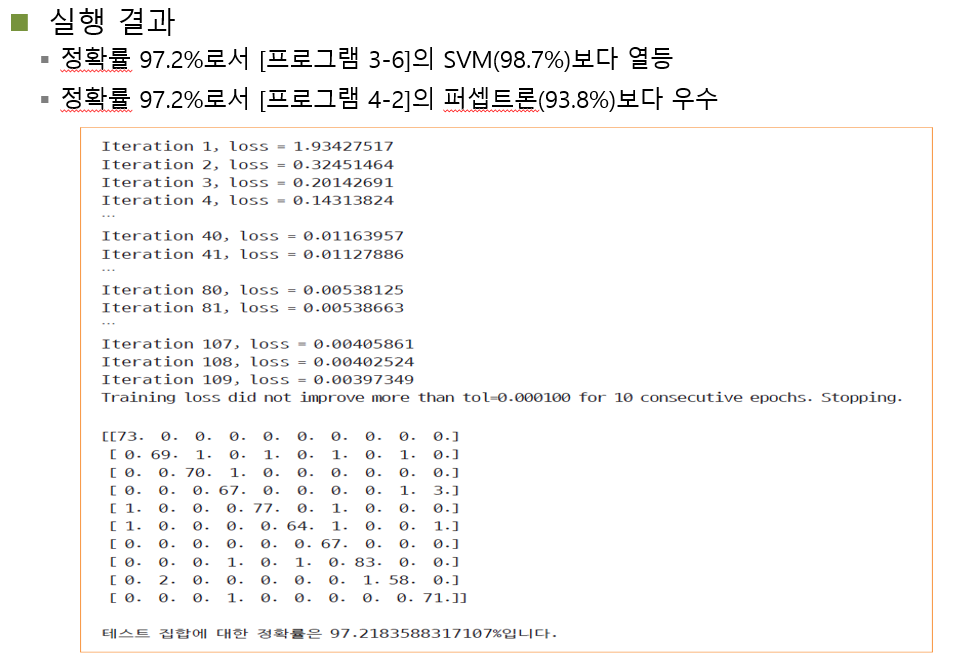

In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 OpenML에서 MNIST(28x28 손글씨 숫자 이미지) 데이터셋을 불러와,
# 사이킷런의 MLPClassifier(다층 퍼셉트론)을 학습한 뒤,
# 테스트 데이터에 대해 예측을 수행하고,
# 혼동 행렬 및 정확률을 계산하여 모델 성능을 평가하는 예제임.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: MNIST 데이터셋 로딩 및 정규화
# 2단계: 훈련/테스트 데이터로 분할
# 3단계: MLPClassifier 모델 구성 및 학습 수행
# 4단계: 테스트 데이터 예측
# 5단계: 혼동 행렬 계산 및 출력
# 6단계: 정확률 계산 및 출력
# ------------------------------------------------------------

from sklearn.datasets import fetch_openml          # OpenML에서 데이터셋을 로딩하기 위한 함수 임포트
from sklearn.neural_network import MLPClassifier   # 다층 퍼셉트론 분류기 클래스 임포트
import matplotlib.pyplot as plt                    # 시각화를 위한 matplotlib 모듈 임포트 (현재 코드에서는 미사용)
import numpy as np                                 # 수치 계산 및 배열 처리를 위한 numpy 임포트

# ------------------------------------------------------------
# [1단계] MNIST 데이터셋 로딩 및 정규화
# ------------------------------------------------------------

mnist = fetch_openml('mnist_784')  
# OpenML에서 MNIST 데이터셋(mnist_784)을 로딩함 (70,000개 샘플, 784차원 입력)

mnist.data = mnist.data / 255.0  
# 입력 데이터(픽셀 값)를 0~1 범위로 정규화하여 학습 안정성을 높임

# ------------------------------------------------------------
# [2단계] 훈련/테스트 데이터 분할
# ------------------------------------------------------------

x_train = mnist.data[:60000]  
# 앞 60,000개 샘플을 훈련 집합으로 지정

x_test = mnist.data[60000:]  
# 뒤 10,000개 샘플을 테스트 집합으로 지정

y_train = np.int16(mnist.target[:60000])  
# 문자열 형태의 타겟을 int형으로 변환하여 훈련 라벨로 사용

y_test = np.int16(mnist.target[60000:])  
# 문자열 형태의 타겟을 int형으로 변환하여 테스트 라벨로 사용

# ------------------------------------------------------------
# [3단계] MLP 분류기 구성 및 학습
# ------------------------------------------------------------

mlp = MLPClassifier(
    hidden_layer_sizes=(100),         # 은닉층을 하나 두고 뉴런 수를 100개로 설정
    learning_rate_init=0.001,         # 초기 학습률을 0.001로 설정
    batch_size=512,                   # 미니배치 크기를 512로 설정
    max_iter=300,                     # 최대 학습 반복 횟수를 300으로 설정
    solver='adam',                    # Adam 최적화 알고리즘 사용
    verbose=True                      # 학습 진행 상태 출력
)

mlp.fit(x_train, y_train)  
# 훈련 데이터와 라벨을 이용해 MLP 모델을 학습시킴

# ------------------------------------------------------------
# [4단계] 테스트 데이터 예측
# ------------------------------------------------------------

res = mlp.predict(x_test)  
# 학습된 모델을 이용하여 테스트 데이터에 대한 예측 수행

# ------------------------------------------------------------
# [5단계] 혼동 행렬 계산
# ------------------------------------------------------------

conf = np.zeros((10, 10), dtype=np.int16)  
# 예측 라벨 vs 실제 라벨 대응을 기록할 10x10 혼동 행렬 초기화 (각 숫자 라벨마다)

for i in range(len(res)):
    conf[res[i]][y_test[i]] += 1  
    # 예측값(res[i])과 실제값(y_test[i])에 해당하는 위치의 값을 1씩 증가시킴

print(conf)  
# 계산된 혼동 행렬을 출력하여 분류 성능을 시각적으로 확인함

# ------------------------------------------------------------
# [6단계] 정확률 계산 및 출력
# ------------------------------------------------------------

no_correct = 0  
# 정확히 예측한 샘플 수를 누적할 변수 초기화

for i in range(10):
    no_correct += conf[i][i]  
    # 각 숫자 라벨에 대해 예측이 맞은 경우(conf[i][i])를 모두 합산함

accuracy = no_correct / len(res)  
# 전체 테스트 샘플 중 정확하게 예측한 비율을 계산함

print("테스트 집합에 대한 정확률은", accuracy * 100, "%입니다.")  
# 정확률을 백분율로 환산하여 출력함


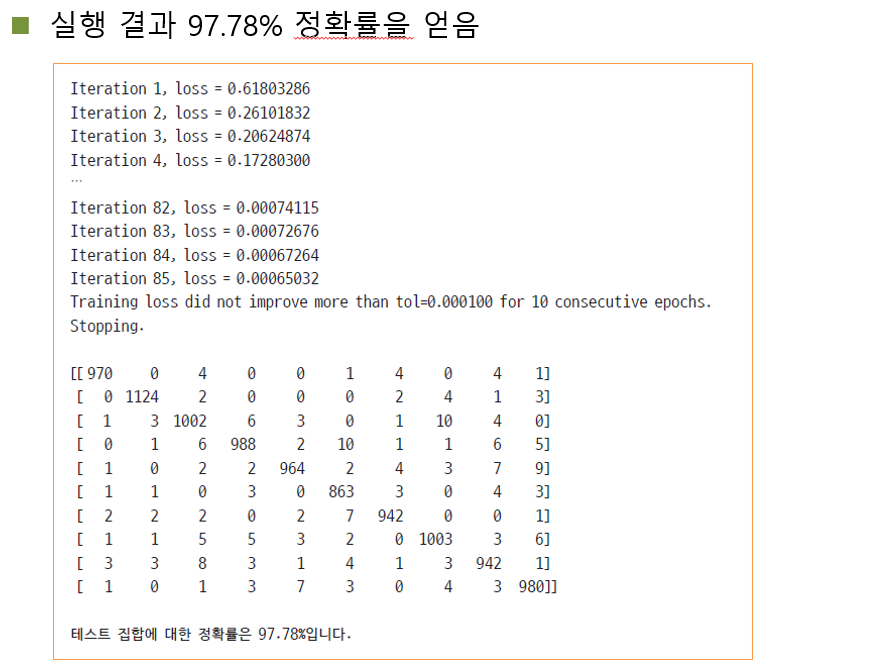

하이퍼 매개변수 최적화에 걸린 시간은 60.907795906066895 초입니다.


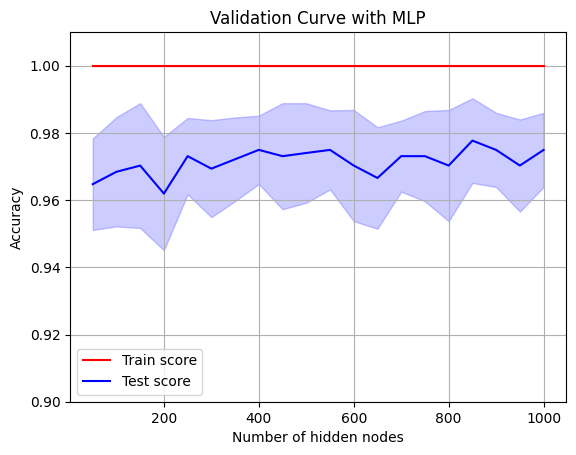


최적의 은닉층의 노드 개수는 850 개입니다.

[[74.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 69.  0.  0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0. 81.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0. 68.  0.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  0. 68.  0.  0.  0.  0.  0.]
 [ 1.  0.  0.  3.  0. 56.  1.  0.  0.  1.]
 [ 0.  0.  0.  0.  0.  1. 69.  0.  0.  0.]
 [ 0.  0.  0.  0.  1.  0.  0. 69.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  1.  0. 72.  0.]
 [ 0.  0.  0.  1.  2.  1.  0.  1.  0. 76.]]
테스트 집합에 대한 정확률은 97.63560500695411 %입니다.


In [ ]:
# ------------------------------------------------------------
# [전체 개요: Overview]
# 본 코드는 sklearn의 손글씨 숫자 데이터셋(digits)을 기반으로,
# MLPClassifier의 은닉층 노드 수(`hidden_layer_sizes`)를 50부터 1000까지 변화시키며
# 각 구성에 대해 10-겹 교차검증(validation_curve)을 수행함으로써 성능을 평가하고,
# 그 결과를 시각화하여 최적 노드 수를 선택함.
# 이후, 선택된 은닉 노드 수로 모델을 재학습하고,
# 테스트 집합에 대한 예측 정확도 및 혼동 행렬을 출력함.

# ------------------------------------------------------------
# [처리 흐름: Step-by-step Flow]
# 1단계: 데이터 로딩 및 학습/테스트 분할
# 2단계: MLP 분류기 정의 및 validation_curve 수행 (교차 검증)
# 3단계: 교차 검증 평균 정확도 및 표준편차 계산
# 4단계: 정확도 시각화 그래프 출력
# 5단계: 최적 노드 수 탐색 및 모델 재학습
# 6단계: 예측 수행, 혼동 행렬 생성, 정확률 계산 및 출력
# ------------------------------------------------------------

from sklearn import datasets  # 손글씨 숫자 이미지 데이터를 포함한 digits 데이터셋 로딩용 모듈 임포트
from sklearn.neural_network import MLPClassifier  # 다층 퍼셉트론(MLP) 분류기 클래스 임포트
from sklearn.model_selection import train_test_split, validation_curve  # 학습/검증 분할 및 하이퍼파라미터 검증용 함수 임포트
import numpy as np  # 수치 연산 및 배열 처리 기능 제공 모듈 임포트
import matplotlib.pyplot as plt  # 결과 시각화를 위한 matplotlib 시각화 모듈 임포트
import time  # 모델 수행 시간 측정을 위한 time 모듈 임포트

# 1단계. 데이터셋 로딩 및 훈련/테스트 집합 분할
digit = datasets.load_digits()  # sklearn에서 제공하는 손글씨 숫자 이미지 데이터셋 로딩
x_train, x_test, y_train, y_test = train_test_split(
    digit.data, digit.target, train_size=0.6
)  # 전체 데이터를 60% 훈련용, 40% 테스트용으로 무작위 분할 수행

# 2단계. 다층 퍼셉트론 모델에 대해 hidden_layer_sizes 하이퍼파라미터 튜닝 실시
start = time.time()  # validation_curve 수행 전 시작 시간 기록

mlp = MLPClassifier(
    learning_rate_init=0.001,  # 초기 학습률 설정 (너무 크면 발산, 너무 작으면 수렴 느림)
    batch_size=32,             # 한 번에 업데이트할 미니배치 크기 설정
    max_iter=300,              # 학습 반복 횟수(에폭 수) 제한
    solver='sgd'               # 최적화 방식으로 확률적 경사 하강법(SGD) 사용
)  # 하이퍼파라미터 기본 설정된 MLP 분류기 객체 정의

prange = range(50, 1001, 50)  # 실험에 사용할 은닉 노드 개수 범위를 50부터 1000까지 50 단위로 생성

train_score, test_score = validation_curve(
    mlp,                       # MLP 모델 객체
    x_train, y_train,          # 훈련 데이터셋 입력 및 라벨
    param_name="hidden_layer_sizes",  # 실험할 하이퍼파라미터 이름
    param_range=prange,       # 실험할 파라미터 값 목록 (은닉 노드 수)
    cv=10,                    # 10-겹 교차 검증을 수행
    scoring="accuracy",       # 모델 성능 지표로 정확도(accuracy) 사용
    n_jobs=4                  # 병렬 처리를 위한 CPU 코어 수 설정 (최대 4개 사용)
)

end = time.time()  # 교차 검증 종료 시간 기록
print("하이퍼 매개변수 최적화에 걸린 시간은", end - start, "초입니다.")  # 수행 소요 시간 출력

# 3단계. 교차 검증 결과(정확도)의 평균 및 표준편차 계산
train_mean = np.mean(train_score, axis=1)  # 각 노드 수에 대해 훈련 정확도의 평균 계산
train_std = np.std(train_score, axis=1)    # 각 노드 수에 대해 훈련 정확도의 표준편차 계산
test_mean = np.mean(test_score, axis=1)    # 각 노드 수에 대해 검증 정확도의 평균 계산
test_std = np.std(test_score, axis=1)      # 각 노드 수에 대해 검증 정확도의 표준편차 계산

# 4단계. 평균 정확도 및 신뢰 구간 시각화
plt.plot(prange, train_mean, label="Train score", color="r")  # 훈련 정확도 평균에 대한 선 그래프 출력 (붉은색)
plt.plot(prange, test_mean, label="Test score", color="b")    # 검증 정확도 평균에 대한 선 그래프 출력 (파란색)

# 평균 ± 표준편차 영역을 음영으로 표시하여 신뢰 구간 시각화
plt.fill_between(prange, train_mean - train_std, train_mean + train_std, alpha=0.2, color="r")  
plt.fill_between(prange, test_mean - test_std, test_mean + test_std, alpha=0.2, color="b")  

# 그래프 옵션 설정
plt.legend(loc="best")  # 범례 위치 자동 설정
plt.title("Validation Curve with MLP")  # 그래프 제목 설정
plt.xlabel("Number of hidden nodes")    # x축 레이블 설정
plt.ylabel("Accuracy")                  # y축 레이블 설정
plt.ylim(0.9, 1.01)                     # y축 값 범위 설정
plt.grid(axis='both')                   # x축과 y축 모두에 대해 격자 표시
plt.show()  # 그래프 화면에 출력

# 5단계. 검증 정확도 기준으로 최적의 은닉 노드 수 선택
best_number_nodes = prange[np.argmax(test_mean)]  # 검증 정확도가 가장 높은 인덱스를 찾아 해당 노드 수를 선택
print("\n최적의 은닉층의 노드 개수는", best_number_nodes, "개입니다.\n")  # 최적 노드 수 출력

# 6단계. 최적 노드 수를 기반으로 모델 재학습 후 테스트
mlp_test = MLPClassifier(
    hidden_layer_sizes=(best_number_nodes),  # 은닉 노드 수를 최적 값으로 설정
    learning_rate_init=0.001, batch_size=32, max_iter=300, solver='sgd'  # 동일 하이퍼파라미터 유지
)
mlp_test.fit(x_train, y_train)  # 훈련 데이터로 최종 모델 학습

res = mlp_test.predict(x_test)  # 테스트 데이터에 대한 예측 수행

# 혼동 행렬 생성
conf = np.zeros((10, 10))  # 0~9 숫자 클래스별 혼동 행렬을 저장할 10x10 배열 초기화
for i in range(len(res)):
    conf[res[i]][y_test[i]] += 1  # 예측 결과(res)와 실제 라벨(y_test)을 기준으로 혼동 행렬 값 증가

print(conf)  # 혼동 행렬 출력

# 테스트 정확률 계산
no_correct = 0  # 정확히 맞춘 샘플 수 저장 변수 초기화
for i in range(10):
    no_correct += conf[i][i]  # 각 클래스에 대해 정답으로 예측된 샘플 수(대각선 값)를 누적합

accuracy = no_correct / len(res)  # 전체 샘플 수에 대한 정확도 계산
print("테스트 집합에 대한 정확률은", accuracy * 100, "%입니다.")  # 정확도를 백분율로 출력


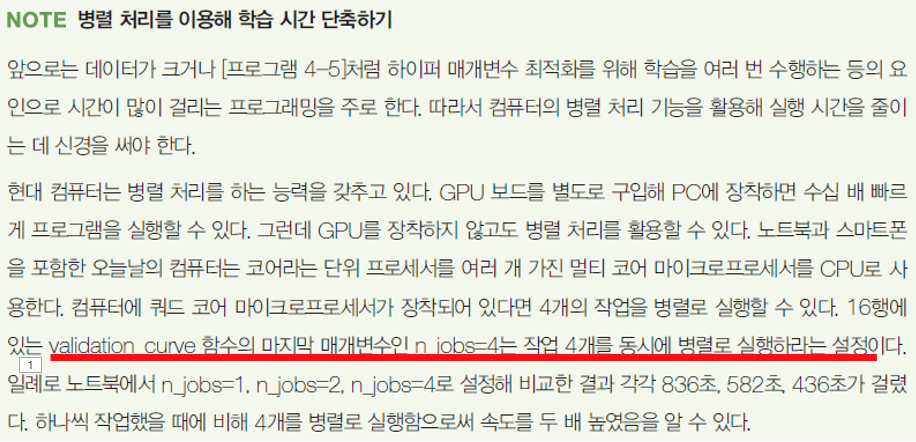